<a href="https://colab.research.google.com/github/SaturninoRM372790/FASE1_TECH_CHALLENGE/blob/main/Tech_Challeng_Fase1_Olist_EDMAR_SUELLEN.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
print('Hello World FIAP')

Hello World FIAP


# Tech Challenge – Fase 1 – Olist


## 1 - Objetivo

In [ ]:
# Registrar, de forma organizada e replicável, as etapas da análise exploratória realizada com o dataset público da Olist.
# O foco do Tech Challeng é investigar padrões e relações buscando gerar insights a partir dos dados.

## 2 - Metodologia KDD

In [ ]:
# Foi utilizada a metodologia KDD (Knowledge Discovery in Databases), organizada nas seguintes etapas:
# 1. Seleção dos dados;
# 2. Pré-processamento e Limpeza dos dados;
# 3. Transformação;
# 4. Análise dos dados;
# 5. Interpretação dos resultados.

#A estrutura deste notebook segue essa lógica, de forma a facilitar o rastreamento do que foi feito e permitir a replicação da análise pelos participantes do grupo ou qualquer pessoa.

## 3 - Importar bibliotecas

In [ ]:
# Nesta etapa, foram importadas as bibliotecas necessárias para leitura, tratamento, análise e visualização dos dados.

# Manipulação dos dados
import pandas as pd
import numpy as np

# visualização dos dados
import seaborn as sns
import matplotlib.pyplot as plt
import plotly.express as px

# Interação com sistema
import os
import zipfile

# Visual dos gráficos
sns.set_theme(style="whitegrid")

# Configurações básicas para visualização
pd.set_option('display.max_columns', 100)
pd.set_option('display.float_format', '{:.2f}'.format)

plt.rcParams['figure.figsize'] = (10, 5)

print("Bibliotecas importadas com sucesso.")

Bibliotecas importadas com sucesso.


## 4 - Carregar dataset

In [ ]:
# Nesta etapa, foi feito o carregamento dos arquivos contendo o dataset da Olist.
# Basta clicar na lateral "Arquivos" e arrastar os arquivos CSV.
# Em seguida, o conteúdo é extraído para uso nas próximas análises.

from google.colab import files

uploaded = files.upload()

Saving 6.1 Dataset.zip to 6.1 Dataset (1).zip


In [ ]:
# Verificar arquivos enviados
os.listdir()

zip_name = "6.1 Dataset.zip"

with zipfile.ZipFile(zip_name, 'r') as zip_ref:
    zip_ref.extractall("olist_dataset")

print("Dataset descompactado com sucesso.")

Dataset descompactado com sucesso.


In [ ]:
# conferir arquivos
os.listdir("olist_dataset")

['olist_orders_dataset.csv',
 'olist_customers_dataset.csv',
 'olist_geolocation_dataset.csv',
 'olist_order_reviews_dataset.csv',
 'olist_order_items_dataset.csv',
 'olist_order_payments_dataset.csv',
 'product_category_name_translation.csv',
 'olist_sellers_dataset.csv',
 'olist_products_dataset.csv']

## 5 - Ler os CSVs

In [ ]:
# Nesta etapa, os arquivos CSV foram lidos e armazenados em dataframes (df).

path = "olist_dataset"

orders = pd.read_csv(f"{path}/olist_orders_dataset.csv")
order_items = pd.read_csv(f"{path}/olist_order_items_dataset.csv")
payments = pd.read_csv(f"{path}/olist_order_payments_dataset.csv")
reviews = pd.read_csv(f"{path}/olist_order_reviews_dataset.csv")
customers = pd.read_csv(f"{path}/olist_customers_dataset.csv")
products = pd.read_csv(f"{path}/olist_products_dataset.csv")
sellers = pd.read_csv(f"{path}/olist_sellers_dataset.csv")
category_translation = pd.read_csv(f"{path}/product_category_name_translation.csv")

print("Arquivos CSV lidos com sucesso.")

Arquivos CSV lidos com sucesso.


## 6 - Mostrar estrutura de cada tabela

In [ ]:
# Nesta etapa, foi verificada a estrutura inicial de cada tabela, incluindo quantidade de linhas, colunas e primeiras observações.

tabelas = {
    "orders": orders,
    "order_items": order_items,
    "payments": payments,
    "reviews": reviews,
    "customers": customers,
    "products": products,
    "sellers": sellers,
    "category_translation": category_translation
}

for nome, df in tabelas.items():
    print(f"\nTabela: {nome}")
    print(f"Linhas: {df.shape[0]} | Colunas: {df.shape[1]}")
    display(df.head())


Tabela: orders
Linhas: 99441 | Colunas: 8


,order_id,customer_id,order_status,order_purchase_timestamp,order_approved_at,order_delivered_carrier_date,order_delivered_customer_date,order_estimated_delivery_date
0,e481f51cbdc54678b7cc49136f2d6af7,9ef432eb6251297304e76186b10a928d,delivered,2017-10-02 10:56:33,2017-10-02 11:07:15,2017-10-04 19:55:00,2017-10-10 21:25:13,2017-10-18 00:00:00
1,53cdb2fc8bc7dce0b6741e2150273451,b0830fb4747a6c6d20dea0b8c802d7ef,delivered,2018-07-24 20:41:37,2018-07-26 03:24:27,2018-07-26 14:31:00,2018-08-07 15:27:45,2018-08-13 00:00:00
2,47770eb9100c2d0c44946d9cf07ec65d,41ce2a54c0b03bf3443c3d931a367089,delivered,2018-08-08 08:38:49,2018-08-08 08:55:23,2018-08-08 13:50:00,2018-08-17 18:06:29,2018-09-04 00:00:00
3,949d5b44dbf5de918fe9c16f97b45f8a,f88197465ea7920adcdbec7375364d82,delivered,2017-11-18 19:28:06,2017-11-18 19:45:59,2017-11-22 13:39:59,2017-12-02 00:28:42,2017-12-15 00:00:00
4,ad21c59c0840e6cb83a9ceb5573f8159,8ab97904e6daea8866dbdbc4fb7aad2c,delivered,2018-02-13 21:18:39,2018-02-13 22:20:29,2018-02-14 19:46:34,2018-02-16 18:17:02,2018-02-26 00:00:00



Tabela: order_items
Linhas: 112650 | Colunas: 7


,order_id,order_item_id,product_id,seller_id,shipping_limit_date,price,freight_value
0,00010242fe8c5a6d1ba2dd792cb16214,1,4244733e06e7ecb4970a6e2683c13e61,48436dade18ac8b2bce089ec2a041202,2017-09-19 09:45:35,58.90,13.29
1,00018f77f2f0320c557190d7a144bdd3,1,e5f2d52b802189ee658865ca93d83a8f,dd7ddc04e1b6c2c614352b383efe2d36,2017-05-03 11:05:13,239.90,19.93
2,000229ec398224ef6ca0657da4fc703e,1,c777355d18b72b67abbeef9df44fd0fd,5b51032eddd242adc84c38acab88f23d,2018-01-18 14:48:30,199.00,17.87
3,00024acbcdf0a6daa1e931b038114c75,1,7634da152a4610f1595efa32f14722fc,9d7a1d34a5052409006425275ba1c2b4,2018-08-15 10:10:18,12.99,12.79
4,00042b26cf59d7ce69dfabb4e55b4fd9,1,ac6c3623068f30de03045865e4e10089,df560393f3a51e74553ab94004ba5c87,2017-02-13 13:57:51,199.90,18.14



Tabela: payments
Linhas: 103886 | Colunas: 5


...

,product_id,product_category_name,product_name_lenght,product_description_lenght,product_photos_qty,product_weight_g,product_length_cm,product_height_cm,product_width_cm
0,1e9e8ef04dbcff4541ed26657ea517e5,perfumaria,40.00,287.00,1.00,225.00,16.00,10.00,14.00
1,3aa071139cb16b67ca9e5dea641aaa2f,artes,44.00,276.00,1.00,1000.00,30.00,18.00,20.00
2,96bd76ec8810374ed1b65e291975717f,esporte_lazer,46.00,250.00,1.00,154.00,18.00,9.00,15.00
3,cef67bcfe19066a932b7673e239eb23d,bebes,27.00,261.00,1.00,371.00,26.00,4.00,26.00
4,9dc1a7de274444849c219cff195d0b71,utilidades_domesticas,37.00,402.00,4.00,625.00,20.00,17.00,13.00



Tabela: sellers
Linhas: 3095 | Colunas: 4


,seller_id,seller_zip_code_prefix,seller_city,seller_state
0,3442f8959a84dea7ee197c632cb2df15,13023,campinas,SP
1,d1b65fc7debc3361ea86b5f14c68d2e2,13844,mogi guacu,SP
2,ce3ad9de960102d0677a81f5d0bb7b2d,20031,rio de janeiro,RJ
3,c0f3eea2e14555b6faeea3dd58c1b1c3,4195,sao paulo,SP
4,51a04a8a6bdcb23deccc82b0b80742cf,12914,braganca paulista,SP



Tabela: category_translation
Linhas: 71 | Colunas: 2


,product_category_name,product_category_name_english
0,beleza_saude,health_beauty
1,informatica_acessorios,computers_accessories
2,automotivo,auto
3,cama_mesa_banho,bed_bath_table
4,moveis_decoracao,furniture_decor


## 7 - Verificar nulos e tipos

In [ ]:
# Nesta seção foram verificados os tipos de dados e a existência de valores ausentes.

# Essa etapa é importante para identificar possíveis ajustes antes da análise.

for nome, df in tabelas.items():
    print(f"\nTabela: {nome}")
    print(df.info())


Tabela: orders
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 99441 entries, 0 to 99440
Data columns (total 8 columns):
 #   Column                         Non-Null Count  Dtype 
---  ------                         --------------  ----- 
 0   order_id                       99441 non-null  object
 1   customer_id                    99441 non-null  object
 2   order_status                   99441 non-null  object
 3   order_purchase_timestamp       99441 non-null  object
 4   order_approved_at              99281 non-null  object
 5   order_delivered_carrier_date   97658 non-null  object
 6   order_delivered_customer_date  96476 non-null  object
 7   order_estimated_delivery_date  99441 non-null  object
dtypes: object(8)
memory usage: 6.1+ MB
None

Tabela: order_items
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 112650 entries, 0 to 112649
Data columns (total 7 columns):
 #   Column               Non-Null Count   Dtype  
---  ------               --------------   -----  
 0   ord

In [ ]:
for nome, df in tabelas.items():
    print(f"\nValores nulos na tabela: {nome}")
    nulos = df.isnull().sum()
    nulos = nulos[nulos > 0].sort_values(ascending=False)

    if len(nulos) == 0:
        print("Não há valores nulos.")
    else:
        print(nulos)


Valores nulos na tabela: orders
order_delivered_customer_date    2965
order_delivered_carrier_date     1783
order_approved_at                 160
dtype: int64

Valores nulos na tabela: order_items
Não há valores nulos.

Valores nulos na tabela: payments
Não há valores nulos.

Valores nulos na tabela: reviews
review_comment_title      87656
review_comment_message    58247
dtype: int64

Valores nulos na tabela: customers
Não há valores nulos.

Valores nulos na tabela: products
product_category_name         610
product_name_lenght           610
product_description_lenght    610
product_photos_qty            610
product_weight_g                2
product_length_cm               2
product_height_cm               2
product_width_cm                2
dtype: int64

Valores nulos na tabela: sellers
Não há valores nulos.

Valores nulos na tabela: category_translation
Não há valores nulos.


## 8 - Tratar os dados

In [ ]:
# Nesta etapa foram feitos ajustes nos dados para permitir a análise.

# Os principais tratamentos realizados foram:
  # - conversão de colunas de data;
  # - revisão de valores ausentes;
  # - preparação das tabelas para integração.


In [ ]:
  # - conversão de colunas de data;
date_cols_orders = [
    "order_purchase_timestamp",
    "order_approved_at",
    "order_delivered_carrier_date",
    "order_delivered_customer_date",
    "order_estimated_delivery_date"]

In [ ]:
for col in date_cols_orders:
    orders[col] = pd.to_datetime(orders[col], errors="coerce")


In [ ]:
# Conversão colunas de data na tabela de avaliações
reviews["review_creation_date"] = pd.to_datetime(reviews["review_creation_date"], errors="coerce")
reviews["review_answer_timestamp"] = pd.to_datetime(reviews["review_answer_timestamp"], errors="coerce")

In [ ]:
# Conversão coluna de data limite de envio
order_items["shipping_limit_date"] = pd.to_datetime(order_items["shipping_limit_date"], errors="coerce")

print("Colunas de data convertidas com sucesso.")

Colunas de data convertidas com sucesso.


In [ ]:
# Verificar duplicados
for nome, df in tabelas.items():
    print(f"{nome}: {df.duplicated().sum()} linhas duplicadas")

orders: 0 linhas duplicadas
order_items: 0 linhas duplicadas
payments: 0 linhas duplicadas
reviews: 0 linhas duplicadas
customers: 0 linhas duplicadas
products: 0 linhas duplicadas
sellers: 0 linhas duplicadas
category_translation: 0 linhas duplicadas


## 9 - Fazer os merges

In [ ]:
# Nesta etapa as tabelas são integradas para formar uma base analítica consolidada.

# As principais chaves utilizadas são:
  # - order_id;
  # - customer_id;
  # - product_id;
  # - seller_id.

# A base final permitirá analisar pedidos, clientes, produtos, pagamentos, vendedores e avaliações de forma conjunta.

# Começar pela tabela de pedidos
base = orders.copy()

# Juntar clientes
base = base.merge(customers, on="customer_id", how="left")

# Juntar itens dos pedidos
base = base.merge(order_items, on="order_id", how="left")

# Juntar produtos
base = base.merge(products, on="product_id", how="left")

# Juntar tradução das categorias
base = base.merge(category_translation, on="product_category_name", how="left")

# Juntar vendedores
base = base.merge(sellers, on="seller_id", how="left", suffixes=("_customer", "_seller"))

# Juntar avaliações
base = base.merge(reviews[["order_id", "review_score"]], on="order_id", how="left")

# Juntar pagamentos agregados por pedido
payments_agg = payments.groupby("order_id", as_index=False).agg({
    "payment_value": "sum",
    "payment_installments": "mean"
})

base = base.merge(payments_agg, on="order_id", how="left")

print("Base consolidada criada com sucesso.")
print(base.shape)
display(base.head())

Base consolidada criada com sucesso.
(114092, 33)


,order_id,customer_id,order_status,order_purchase_timestamp,order_approved_at,order_delivered_carrier_date,order_delivered_customer_date,order_estimated_delivery_date,customer_unique_id,customer_zip_code_prefix,customer_city,customer_state,order_item_id,product_id,seller_id,shipping_limit_date,price,freight_value,product_category_name,product_name_lenght,product_description_lenght,product_photos_qty,product_weight_g,product_length_cm,product_height_cm,product_width_cm,product_category_name_english,seller_zip_code_prefix,seller_city,seller_state,review_score,payment_value,payment_installments
0,e481f51cbdc54678b7cc49136f2d6af7,9ef432eb6251297304e76186b10a928d,delivered,2017-10-02 10:56:33,2017-10-02 11:07:15,2017-10-04 19:55:00,2017-10-10 21:25:13,2017-10-18,7c396fd4830fd04220f754e42b4e5bff,3149,sao paulo,SP,1.00,87285b34884572647811a353c7ac498a,3504c0cb71d7fa48d967e0e4c94d59d9,2017-10-06 11:07:15,29.99,8.72,utilidades_domesticas,40.00,268.00,4.00,500.00,19.00,8.00,13.00,housewares,9350.00,maua,SP,4.00,38.71,1.00
1,53cdb2fc8bc7dce0b6741e2150273451,b0830fb4747a6c6d20dea0b8c802d7ef,delivered,2018-07-24 20:41:37,2018-07-26 03:24:27,2018-07-26 14:31:00,2018-08-07 15:27:45,2018-08-13,af07308b275d755c9edb36a90c618231,47813,barreiras,BA,1.00,595fac2a385ac33a80bd5114aec74eb8,289cdb325fb7e7f891c38608bf9e0962,2018-07-30 03:24:27,118.70,22.76,perfumaria,29.00,178.00,1.00,400.00,19.00,13.00,19.00,perfumery,31570.00,belo horizonte,SP,4.00,141.46,1.00
2,47770eb9100c2d0c44946d9cf07ec65d,41ce2a54c0b03bf3443c3d931a367089,delivered,2018-08-08 08:38:49,2018-08-08 08:55:23,2018-08-08 13:50:00,2018-08-17 18:06:29,2018-09-04,3a653a41f6f9fc3d2a113cf8398680e8,75265,vianopolis,GO,1.00,aa4383b373c6aca5d8797843e5594415,4869f7a5dfa277a7dca6462dcf3b52b2,2018-08-13 08:55:23,159.90,19.22,automotivo,46.00,232.00,1.00,420.00,24.00,19.00,21.00,auto,14840.00,guariba,SP,5.00,179.12,3.00
3,949d5b44dbf5de918fe9c16f97b45f8a,f88197465ea7920adcdbec7375364d82,delivered,2017-11-18 19:28:06,2017-11-18 19:45:59,2017-11-22 13:39:59,2017-12-02 00:28:42,2017-12-15,7c142cf63193a1473d2e66489a9ae977,59296,sao goncalo do amarante,RN,1.00,d0b61bfb1de832b15ba9d266ca96e5b0,66922902710d126a0e7d26b0e3805106,2017-11-23 19:45:59,45.00,27.20,pet_shop,59.00,468.00,3.00,450.00,30.00,10.00,20.00,pet_shop,31842.00,belo horizonte,MG,5.00,72.20,1.00
4,ad21c59c0840e6cb83a9ceb5573f8159,8ab97904e6daea8866dbdbc4fb7aad2c,delivered,2018-02-13 21:18:39,2018-02-13 22:20:29,2018-02-14 19:46:34,2018-02-16 18:17:02,2018-02-26,72632f0f9dd73dfee390c9b22eb56dd6,9195,santo andre,SP,1.00,65266b2da20d04dbe00c5c2d3bb7859e,2c9e548be18521d1c43cde1c582c6de8,2018-02-19 20:31:37,19.90,8.72,papelaria,38.00,316.00,4.00,250.00,51.00,15.00,15.00,stationery,8752.00,mogi das cruzes,SP,5.00,28.62,1.00


## 10 - Criar variáveis analíticas

In [ ]:
# 10 - Criar variáveis analíticas

# Nesta etapa foram criadas novas variáveis para apoiar a análise.

# Essas variáveis ajudam a estudar vendas, logística e satisfação dos clientes.

# Criar variáveis temporais
base["ano_compra"] = base["order_purchase_timestamp"].dt.year
base["mes_compra"] = base["order_purchase_timestamp"].dt.month
base["ano_mes_compra"] = base["order_purchase_timestamp"].dt.to_period("M").astype(str)

# Criar variável de tempo de entrega em dias
base["tempo_entrega_dias"] = (
    base["order_delivered_customer_date"] - base["order_purchase_timestamp"]
).dt.days

# Criar variável de atraso
base["dias_atraso"] = (
    base["order_delivered_customer_date"] - base["order_estimated_delivery_date"]
).dt.days

# Pedido atrasado: quando a entrega real foi depois da data estimada
base["pedido_atrasado"] = base["dias_atraso"] > 0

# Valor total do item
base["valor_item_total"] = base["price"] + base["freight_value"]

print("Variáveis analíticas criadas com sucesso.")
display(base[[
    "order_id",
    "ano_mes_compra",
    "tempo_entrega_dias",
    "dias_atraso",
    "pedido_atrasado",
    "review_score",
    "payment_value"
]].head())

Variáveis analíticas criadas com sucesso.


,order_id,ano_mes_compra,tempo_entrega_dias,dias_atraso,pedido_atrasado,review_score,payment_value
0,e481f51cbdc54678b7cc49136f2d6af7,2017-10,8.00,-8.00,False,4.00,38.71
1,53cdb2fc8bc7dce0b6741e2150273451,2018-07,13.00,-6.00,False,4.00,141.46
2,47770eb9100c2d0c44946d9cf07ec65d,2018-08,9.00,-18.00,False,5.00,179.12
3,949d5b44dbf5de918fe9c16f97b45f8a,2017-11,13.00,-13.00,False,5.00,72.20
4,ad21c59c0840e6cb83a9ceb5573f8159,2018-02,2.00,-10.00,False,5.00,28.62


## 11 - Gerar estatísticas descritivas

In [ ]:
# Nesta seção foram calculadas estatísticas descritivas para compreender o comportamento geral dos dados.

# Foram observadas variáveis como valor pago, frete, preço, tempo de entrega e avaliação dos clientes.

variaveis_numericas = [
    "payment_value",
    "price",
    "freight_value",
    "tempo_entrega_dias",
    "dias_atraso",
    "review_score"
]

base[variaveis_numericas].describe()

,payment_value,price,freight_value,tempo_entrega_dias,dias_atraso,review_score
count,114089.00,113314.00,113314.00,110839.00,110839.00,113131.00
mean,180.38,120.48,19.98,12.01,-12.04,4.02
std,273.07,183.28,15.78,9.45,10.16,1.40
min,0.00,0.85,0.00,0.00,-147.00,1.00
25%,65.63,39.90,13.08,6.00,-17.00,4.00
50%,114.33,74.90,16.26,10.00,-13.00,5.00
75%,195.39,134.90,21.15,15.00,-7.00,5.00
max,13664.08,6735.00,409.68,209.00,188.00,5.00


In [ ]:
print("Total de pedidos:", base["order_id"].nunique())
print("Total de clientes:", base["customer_unique_id"].nunique())
print("Total de vendedores:", base["seller_id"].nunique())
print("Total de categorias:", base["product_category_name_english"].nunique())
print("Nota média:", round(base["review_score"].mean(), 2))
print("Tempo médio de entrega:", round(base["tempo_entrega_dias"].mean(), 2), "dias")
print("Percentual de pedidos atrasados:", round(base["pedido_atrasado"].mean() * 100, 2), "%")

Total de pedidos: 99441
Total de clientes: 96096
Total de vendedores: 3095
Total de categorias: 71
Nota média: 4.02
Tempo médio de entrega: 12.01 dias
Percentual de pedidos atrasados: 6.39 %


## 12 - Fazer gráficos

In [ ]:
# Nesta seção foram gerados gráficos para visualizar os principais padrões encontrados na base.

# Os gráficos ajudaram a interpretar melhor as informações e apoiar a resposta à pergunta norteadora.

pedidos_mes = base.groupby("ano_mes_compra")["order_id"].nunique().reset_index()
pedidos_mes.columns = ["ano_mes", "total_pedidos"]

## Gráfico 1 — Pedidos por mês

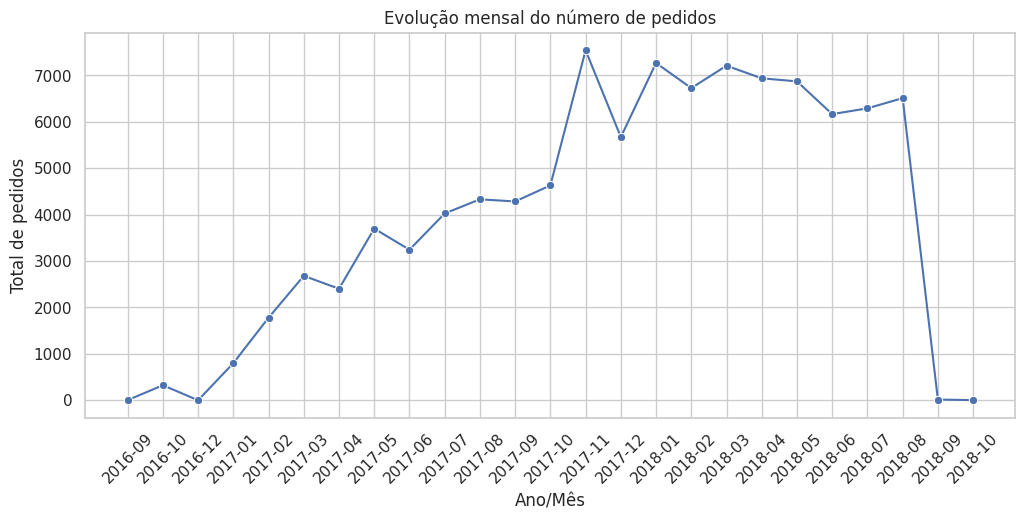

In [ ]:
plt.figure(figsize=(12,5))
sns.lineplot(data=pedidos_mes, x="ano_mes", y="total_pedidos", marker="o")
plt.xticks(rotation=45)
plt.title("Evolução mensal do número de pedidos")
plt.xlabel("Ano/Mês")
plt.ylabel("Total de pedidos")
plt.show()

## Gráfico 2 — Distribuição das Avaliações

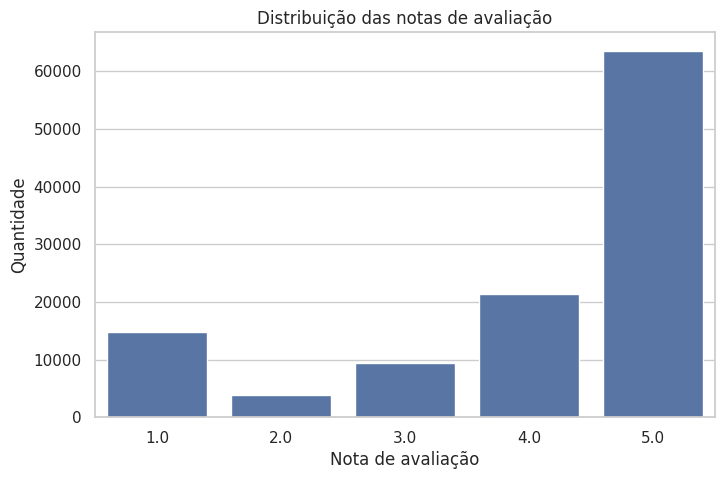

In [ ]:
plt.figure(figsize=(8,5))
sns.countplot(data=base, x="review_score")
plt.title("Distribuição das notas de avaliação")
plt.xlabel("Nota de avaliação")
plt.ylabel("Quantidade")
plt.show()

## Gráfico 3 — Atraso x nota média

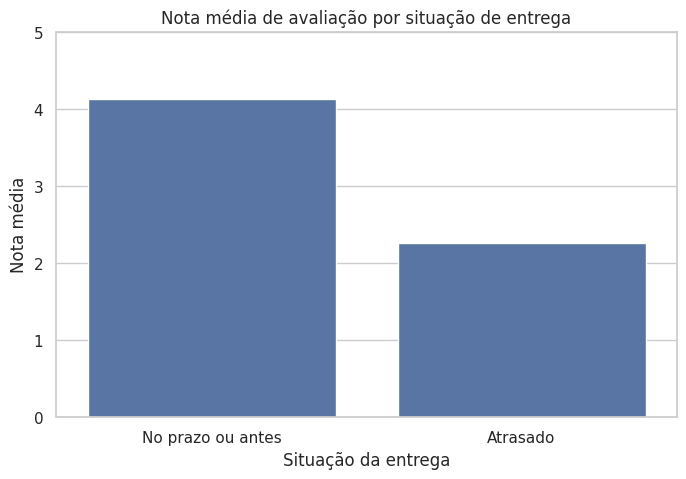

In [ ]:
avaliacao_atraso = base.groupby("pedido_atrasado")["review_score"].mean().reset_index()
avaliacao_atraso["pedido_atrasado"] = avaliacao_atraso["pedido_atrasado"].map({
    False: "No prazo ou antes",
    True: "Atrasado"
})

plt.figure(figsize=(8,5))
sns.barplot(data=avaliacao_atraso, x="pedido_atrasado", y="review_score")
plt.title("Nota média de avaliação por situação de entrega")
plt.xlabel("Situação da entrega")
plt.ylabel("Nota média")
plt.ylim(0, 5)
plt.show()

## Gráfico 4 — Tempo de entrega por nota

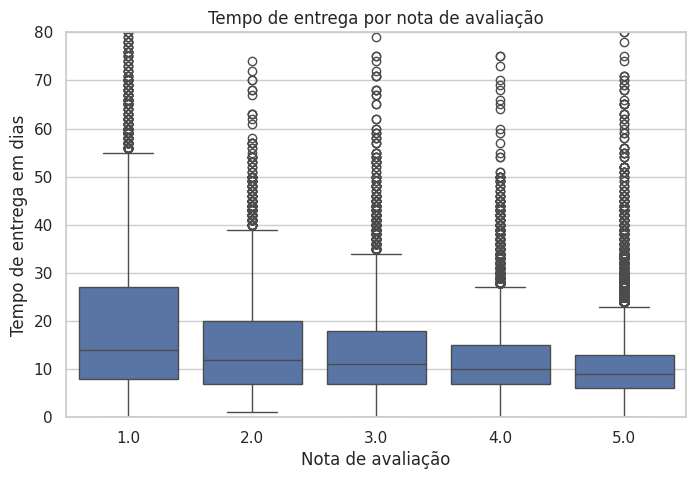

In [ ]:
plt.figure(figsize=(8,5))
sns.boxplot(data=base, x="review_score", y="tempo_entrega_dias")
plt.title("Tempo de entrega por nota de avaliação")
plt.xlabel("Nota de avaliação")
plt.ylabel("Tempo de entrega em dias")
plt.ylim(0, 80)
plt.show()

## Gráfico 5 — Top categorias por pedidos

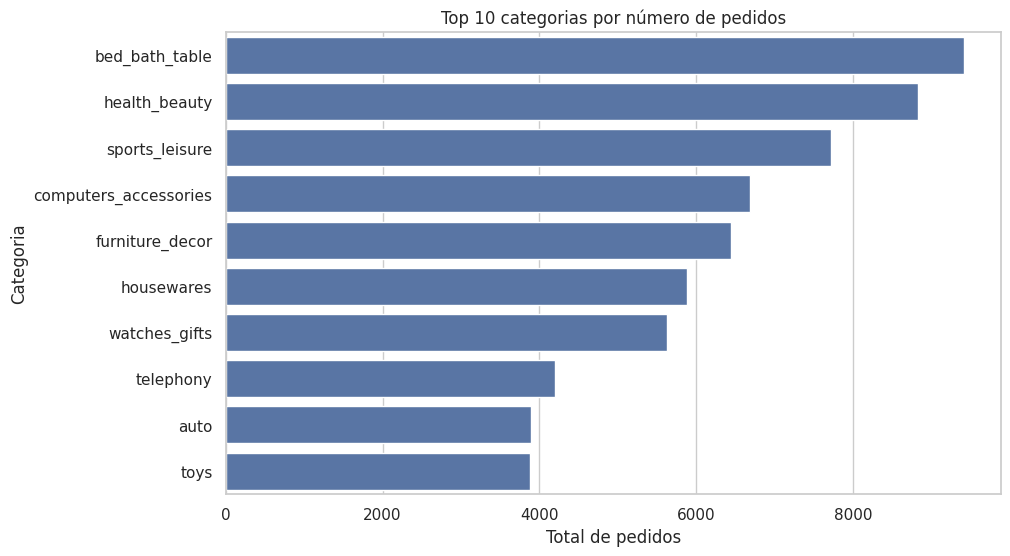

In [ ]:
top_categorias = (
    base.groupby("product_category_name_english")["order_id"]
    .nunique()
    .sort_values(ascending=False)
    .head(10)
    .reset_index()
)

top_categorias.columns = ["categoria", "total_pedidos"]

plt.figure(figsize=(10,6))
sns.barplot(data=top_categorias, y="categoria", x="total_pedidos")
plt.title("Top 10 categorias por número de pedidos")
plt.xlabel("Total de pedidos")
plt.ylabel("Categoria")
plt.show()

## 13 - Analisar hipóteses

In [ ]:
# Nesta seção foram avaliadas algumas hipóteses relacionadas à pergunta norteadora.

# As hipóteses foram definidas para orientar a análise e facilitar a interpretação dos resultados.

## Hipótese 1

In [ ]:
# Pedidos com atraso na entrega tendem a receber avaliações mais baixas.

# Para analisar essa hipótese, foi comparada a nota média dos pedidos entregues no prazo com a nota média dos pedidos atrasados.

hipotese_1 = base.groupby("pedido_atrasado").agg(
    total_pedidos=("order_id", "nunique"),
    nota_media=("review_score", "mean"),
    tempo_medio_entrega=("tempo_entrega_dias", "mean")
).reset_index()

hipotese_1["pedido_atrasado"] = hipotese_1["pedido_atrasado"].map({
    False: "No prazo ou antes",
    True: "Atrasado"
})

hipotese_1

,pedido_atrasado,total_pedidos,nota_media,tempo_medio_entrega
0,No prazo ou antes,92906,4.14,10.51
1,Atrasado,6535,2.26,33.35


In [ ]:
# A análise permitiu comparar se os pedidos atrasados apresentaram, em média, avaliações menores que os pedidos entregues no prazo ou antes do prazo estimado.

## Hipótese 2


In [ ]:
# Algumas categorias de produtos concentram maior volume de pedidos e podem apresentar diferenças no desempenho logístico e na satisfação.

hipotese_2 = (
    base.groupby("product_category_name_english")
    .agg(
        total_pedidos=("order_id", "nunique"),
        nota_media=("review_score", "mean"),
        tempo_medio_entrega=("tempo_entrega_dias", "mean"),
        percentual_atraso=("pedido_atrasado", "mean")
    )
    .reset_index()
)

hipotese_2["percentual_atraso"] = hipotese_2["percentual_atraso"] * 100

hipotese_2 = hipotese_2.sort_values("total_pedidos", ascending=False).head(10)

hipotese_2


,product_category_name_english,total_pedidos,nota_media,tempo_medio_entrega,percentual_atraso
7,bed_bath_table,9417,3.90,12.34,6.93
43,health_beauty,8836,4.14,11.52,7.41
65,sports_leisure,7720,4.11,11.69,6.11
15,computers_accessories,6689,3.93,12.80,6.31
39,furniture_decor,6449,3.90,12.40,6.83
49,housewares,5884,4.06,10.46,4.86
70,watches_gifts,5624,4.02,12.19,7.05
68,telephony,4199,3.95,12.39,6.77
5,auto,3897,4.07,11.77,6.86
69,toys,3886,4.16,11.24,6.25


## Hipótese 3

In [ ]:
# O desempenho logístico pode variar entre os estados dos clientes.

# Para avaliar essa hipótese, será observado o tempo médio de entrega e o percentual de atraso por estado.1

hipotese_3 = (
    base.groupby("customer_state")
    .agg(
        total_pedidos=("order_id", "nunique"),
        nota_media=("review_score", "mean"),
        tempo_medio_entrega=("tempo_entrega_dias", "mean"),
        percentual_atraso=("pedido_atrasado", "mean")
    )
    .reset_index()
)

hipotese_3["percentual_atraso"] = hipotese_3["percentual_atraso"] * 100

hipotese_3.sort_values("tempo_medio_entrega", ascending=False).head(10)

,customer_state,total_pedidos,nota_media,tempo_medio_entrega,percentual_atraso
21,RR,46,3.58,27.83,9.62
3,AP,68,4.22,27.75,3.66
2,AM,148,4.06,25.93,2.99
1,AL,413,3.71,23.98,20.00
13,PA,975,3.78,23.31,10.90
9,MA,747,3.70,21.14,17.22
24,SE,350,3.81,20.98,15.64
5,CE,1336,3.79,20.53,13.07
0,AC,81,4.10,20.33,3.26
14,PB,536,3.99,20.10,10.38


## 14 - Demais gráficos e dados

In [ ]:
# Garantir que colunas de data estejam no formato datetime
date_cols_orders = [
    "order_purchase_timestamp",
    "order_approved_at",
    "order_delivered_carrier_date",
    "order_delivered_customer_date",
    "order_estimated_delivery_date"
]

for col in date_cols_orders:
    orders[col] = pd.to_datetime(orders[col], errors="coerce")

reviews["review_creation_date"] = pd.to_datetime(reviews["review_creation_date"], errors="coerce")
reviews["review_answer_timestamp"] = pd.to_datetime(reviews["review_answer_timestamp"], errors="coerce")
order_items["shipping_limit_date"] = pd.to_datetime(order_items["shipping_limit_date"], errors="coerce")

# Reviews únicos por pedido
reviews_unicos = (
    reviews
    .sort_values("review_answer_timestamp")
    .drop_duplicates(subset="order_id", keep="last")
)

# Pagamentos agregados por pedido
payments_agg = (
    payments
    .groupby("order_id", as_index=False)
    .agg(
        payment_value=("payment_value", "sum"),
        payment_installments=("payment_installments", "mean")
    )
)

# Base no nível de Pedido

base_pedidos = (
    orders
    .merge(customers[["customer_id", "customer_state"]], on="customer_id", how="left")
    .merge(payments_agg, on="order_id", how="left")
    .merge(reviews_unicos[["order_id", "review_score"]], on="order_id", how="left")
)

# Filtrar pedidos entregues para as análises principais
base_entregues = base_pedidos[base_pedidos["order_status"] == "delivered"].copy()

# Variáveis analíticas
base_entregues["tempo_entrega_dias"] = (
    base_entregues["order_delivered_customer_date"] - base_entregues["order_purchase_timestamp"]
).dt.total_seconds() / 86400

base_entregues["dias_atraso"] = (
    base_entregues["order_delivered_customer_date"] - base_entregues["order_estimated_delivery_date"]
).dt.total_seconds() / 86400

base_entregues["pedido_atrasado"] = base_entregues["dias_atraso"] > 0
base_entregues["ano"] = base_entregues["order_purchase_timestamp"].dt.year
base_entregues["mes"] = base_entregues["order_purchase_timestamp"].dt.month
base_entregues["ano_mes"] = base_entregues["order_purchase_timestamp"].dt.to_period("M").astype(str)

# Base no nível item/categoria
base_itens = (
    base_entregues[
        [
            "order_id",
            "order_purchase_timestamp",
            "order_delivered_customer_date",
            "order_estimated_delivery_date",
            "tempo_entrega_dias",
            "pedido_atrasado",
            "review_score"
        ]
    ]
    .merge(order_items[["order_id", "product_id", "price", "freight_value"]], on="order_id", how="left")
    .merge(products[["product_id", "product_category_name"]], on="product_id", how="left")
    .merge(category_translation, on="product_category_name", how="left")
)

base_itens["receita_item"] = base_itens["price"] + base_itens["freight_value"]

# Consolidação por pedido + categoria
base_categoria = (
    base_itens
    .groupby(["order_id", "product_category_name_english"], as_index=False)
    .agg(
        receita=("receita_item", "sum"),
        review_score=("review_score", "first"),
        pedido_atrasado=("pedido_atrasado", "first"),
        tempo_entrega_dias=("tempo_entrega_dias", "first")
    )
)

print("Base padrão criada com sucesso.")
print("Pedidos totais:", base_pedidos["order_id"].nunique())
print("Pedidos entregues:", base_entregues["order_id"].nunique())


Base padrão criada com sucesso.
Pedidos totais: 99441
Pedidos entregues: 96478


In [ ]:
# Resumo numérico

pedidos_analisados = base_pedidos["order_id"].nunique()
pedidos_entregues = base_entregues["order_id"].nunique()
perc_entregues = pedidos_entregues / pedidos_analisados * 100

receita_observada = base_entregues["payment_value"].sum()
ticket_medio = receita_observada / pedidos_entregues
prazo_medio = base_entregues["tempo_entrega_dias"].mean()
perc_atrasos = base_entregues["pedido_atrasado"].mean() * 100
nota_media = base_entregues["review_score"].mean()

resumo_numerico = pd.DataFrame({
    "Indicador": [
        "Pedidos analisados",
        "Pedidos entregues",
        "Receita observada",
        "Ticket médio",
        "Prazo médio de entrega",
        "Pedidos atrasados",
        "Nota média dos reviews"
    ],
    "Valor": [
        f"{pedidos_analisados:,.0f}".replace(",", "."),
        f"{pedidos_entregues:,.0f} ({perc_entregues:.1f}%)".replace(",", "."),
        f"R$ {receita_observada:,.2f}".replace(",", "X").replace(".", ",").replace("X", "."),
        f"R$ {ticket_medio:,.2f}".replace(",", "X").replace(".", ",").replace("X", "."),
        f"{prazo_medio:.1f} dias",
        f"{perc_atrasos:.1f}%",
        f"{nota_media:.2f}"
    ]
})

resumo_numerico

,Indicador,Valor
0,Pedidos analisados,99.441
1,Pedidos entregues,96.478 (97.0%)
2,Receita observada,"R$ 15.422.461,77"
3,Ticket médio,"R$ 159,85"
4,Prazo médio de entrega,12.6 dias
5,Pedidos atrasados,8.1%
6,Nota média dos reviews,4.16


In [ ]:
# Crescimento anual

crescimento_anual = (
    base_entregues
    .groupby("ano", as_index=False)
    .agg(
        pedidos=("order_id", "nunique"),
        receita=("payment_value", "sum")
    )
)

crescimento_anual

,ano,pedidos,receita
0,2016,267,46586.33
1,2017,43428,6922900.24
2,2018,52783,8452975.20


In [ ]:
# Cálculo do crescimento 2017 x 2018
pedidos_2017 = crescimento_anual.loc[crescimento_anual["ano"] == 2017, "pedidos"].iloc[0]
pedidos_2018 = crescimento_anual.loc[crescimento_anual["ano"] == 2018, "pedidos"].iloc[0]

receita_2017 = crescimento_anual.loc[crescimento_anual["ano"] == 2017, "receita"].iloc[0]
receita_2018 = crescimento_anual.loc[crescimento_anual["ano"] == 2018, "receita"].iloc[0]

crescimento_pedidos = (pedidos_2018 - pedidos_2017) / pedidos_2017 * 100
crescimento_receita = (receita_2018 - receita_2017) / receita_2017 * 100

print(f"Crescimento de pedidos (2017 -> 2018): {crescimento_pedidos:.1f}%")
print(f"Crescimento de receita (2017 -> 2018): {crescimento_receita:.1f}%")

Crescimento de pedidos (2017 -> 2018): 21.5%
Crescimento de receita (2017 -> 2018): 22.1%


In [ ]:
# Melhorando as cores
AZUL = "#2F5D7E"       # pedidos / volume
VERDE = "#556B2F"      # receita
TERRACOTA = "#A65D57"  # atraso / risco logístico
DOURADO = "#B08D57"    # satisfação / nota
CINZA = "#6B7280"      # apoio / neutro

sns.set_theme(style="whitegrid")

plt.rcParams["figure.figsize"] = (10, 5)
plt.rcParams["axes.titlesize"] = 13
plt.rcParams["axes.labelsize"] = 11
plt.rcParams["xtick.labelsize"] = 10
plt.rcParams["ytick.labelsize"] = 10
plt.rcParams["legend.fontsize"] = 10
plt.rcParams["axes.edgecolor"] = "#D0D0D0"
plt.rcParams["grid.color"] = "#E6E6E6"
plt.rcParams["grid.linestyle"] = "-"
plt.rcParams["grid.alpha"] = 0.6

print("Paleta padrão configurada com sucesso.")

Paleta padrão configurada com sucesso.


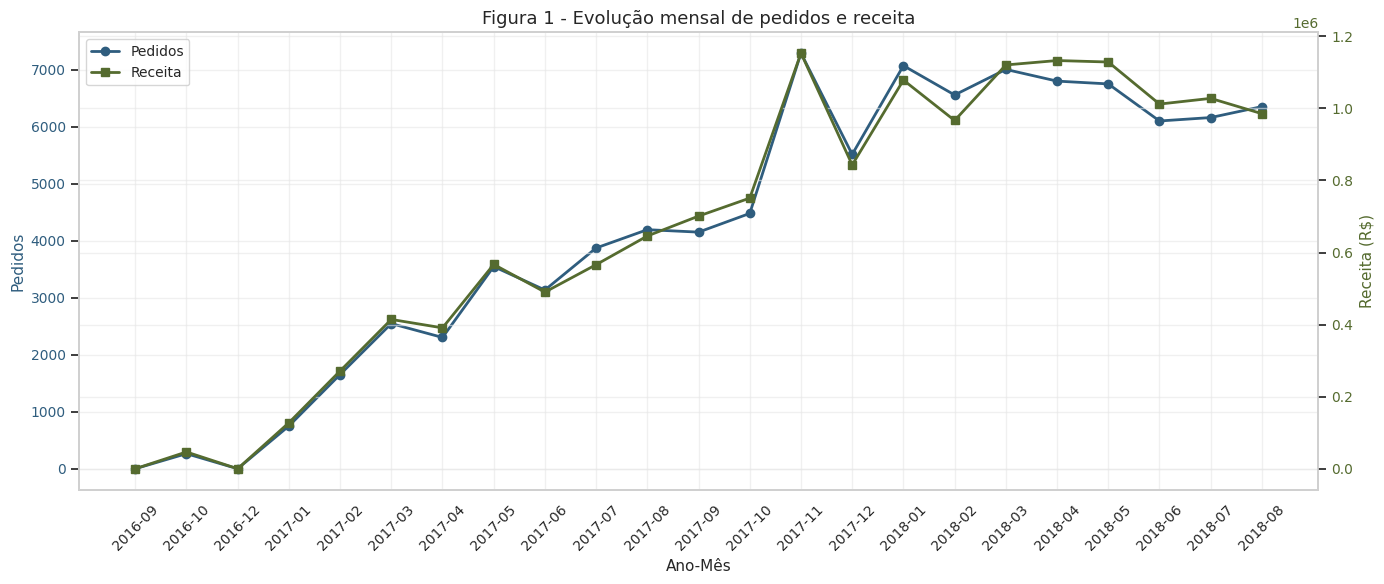

In [ ]:
# Figura - Evolução Mensal

evolucao_mensal = (
    base_entregues
    .groupby("ano_mes", as_index=False)
    .agg(
        pedidos=("order_id", "nunique"),
        receita=("payment_value", "sum")
    )
)

fig, ax1 = plt.subplots(figsize=(14, 6))

linha1 = ax1.plot(
    evolucao_mensal["ano_mes"],
    evolucao_mensal["pedidos"],
    marker="o",
    color=AZUL,
    linewidth=2,
    label="Pedidos"
)
ax1.set_xlabel("Ano-Mês")
ax1.set_ylabel("Pedidos", color=AZUL)
ax1.tick_params(axis="y", labelcolor=AZUL)
ax1.tick_params(axis="x", rotation=45)

ax2 = ax1.twinx()
linha2 = ax2.plot(
    evolucao_mensal["ano_mes"],
    evolucao_mensal["receita"],
    marker="s",
    color=VERDE,
    linewidth=2,
    label="Receita"
)
ax2.set_ylabel("Receita (R$)", color=VERDE)
ax2.tick_params(axis="y", labelcolor=VERDE)

linhas = linha1 + linha2
labels = [l.get_label() for l in linhas]
ax1.legend(linhas, labels, loc="upper left", frameon=True)

plt.title("Figura 1 - Evolução mensal de pedidos e receita")
plt.tight_layout()
plt.show()

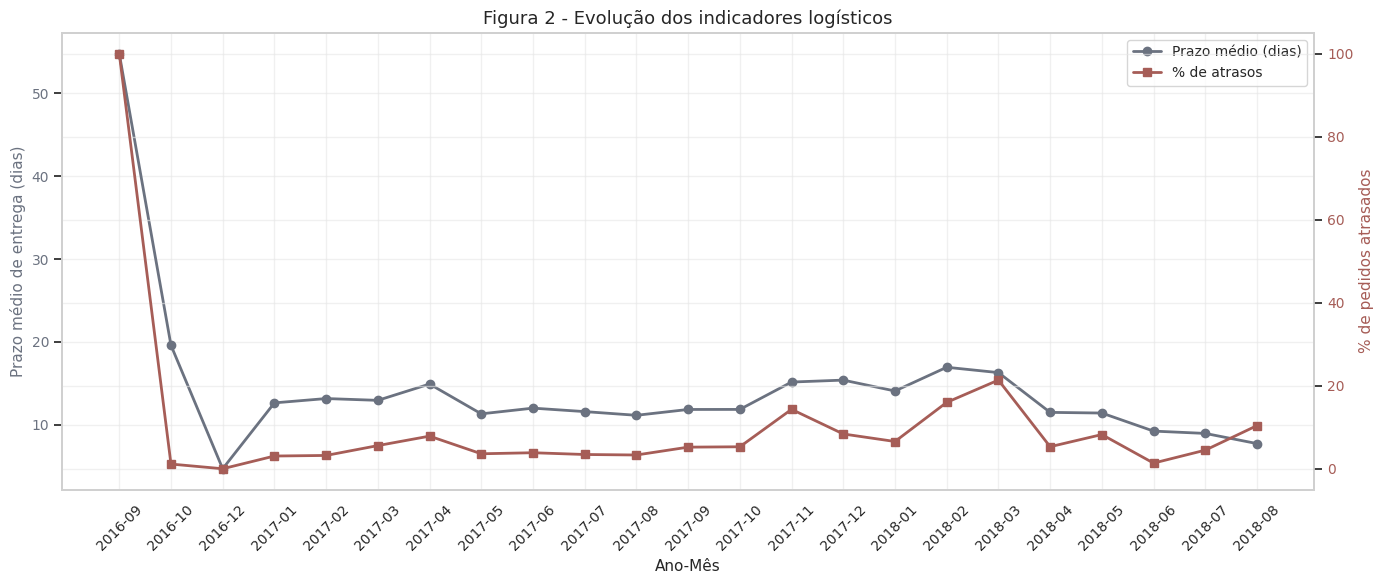

In [ ]:
# Figura Indicadores Logísticos

indicadores_logisticos = (
    base_entregues
    .groupby("ano_mes", as_index=False)
    .agg(
        prazo_medio=("tempo_entrega_dias", "mean"),
        perc_atrasos=("pedido_atrasado", "mean")
    )
)

indicadores_logisticos["perc_atrasos"] = indicadores_logisticos["perc_atrasos"] * 100

fig, ax1 = plt.subplots(figsize=(14, 6))

linha1 = ax1.plot(
    indicadores_logisticos["ano_mes"],
    indicadores_logisticos["prazo_medio"],
    marker="o",
    color=CINZA,
    linewidth=2,
    label="Prazo médio (dias)"
)
ax1.set_xlabel("Ano-Mês")
ax1.set_ylabel("Prazo médio de entrega (dias)", color=CINZA)
ax1.tick_params(axis="y", labelcolor=CINZA)
ax1.tick_params(axis="x", rotation=45)

ax2 = ax1.twinx()
linha2 = ax2.plot(
    indicadores_logisticos["ano_mes"],
    indicadores_logisticos["perc_atrasos"],
    marker="s",
    color=TERRACOTA,
    linewidth=2,
    label="% de atrasos"
)
ax2.set_ylabel("% de pedidos atrasados", color=TERRACOTA)
ax2.tick_params(axis="y", labelcolor=TERRACOTA)

linhas = linha1 + linha2
labels = [l.get_label() for l in linhas]
ax1.legend(linhas, labels, loc="upper right", frameon=True)

plt.title("Figura 2 - Evolução dos indicadores logísticos")
plt.tight_layout()
plt.show()

/tmp/ipykernel_3301/1155047271.py:18: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(


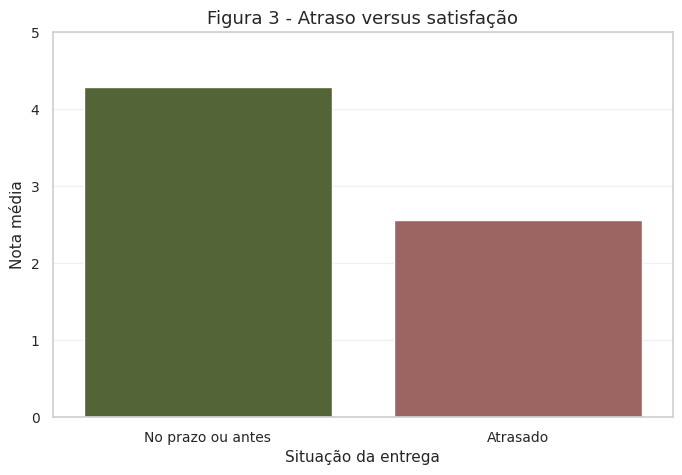

In [ ]:
# Figura Atraso versus Satisfação

atraso_vs_satisfacao = (
    base_entregues
    .groupby("pedido_atrasado", as_index=False)
    .agg(
        pedidos=("order_id", "nunique"),
        nota_media=("review_score", "mean")
    )
)

atraso_vs_satisfacao["pedido_atrasado"] = atraso_vs_satisfacao["pedido_atrasado"].map({
    False: "No prazo ou antes",
    True: "Atrasado"
})

plt.figure(figsize=(8, 5))
sns.barplot(
    data=atraso_vs_satisfacao,
    x="pedido_atrasado",
    y="nota_media",
    palette=[VERDE, TERRACOTA]
)
plt.ylim(0, 5)
plt.xlabel("Situação da entrega")
plt.ylabel("Nota média")
plt.title("Figura 3 - Atraso versus satisfação")
plt.show()

In [ ]:
# Estados com mais atenção
# Critério usado: estados com pelo menos 500 pedidos, ordenados por % de atrasos.
estados = (
    base_entregues
    .groupby("customer_state", as_index=False)
    .agg(
        pedidos=("order_id", "nunique"),
        receita=("payment_value", "sum"),
        nota_media=("review_score", "mean"),
        perc_atrasos=("pedido_atrasado", "mean"),
        prazo_medio=("tempo_entrega_dias", "mean")
    )
)

estados["perc_atrasos"] = estados["perc_atrasos"] * 100

estados_atencao = (
    estados[estados["pedidos"] >= 500]
    .sort_values(["perc_atrasos", "nota_media"], ascending=[False, True])
    .head(8)
    .copy()
)

estados_atencao

estados_atencao_fmt = estados_atencao.copy()

estados_atencao_fmt["receita"] = estados_atencao_fmt["receita"].map(
    lambda x: f"R$ {x:,.2f}".replace(",", "X").replace(".", ",").replace("X", ".")
)
estados_atencao_fmt["nota_media"] = estados_atencao_fmt["nota_media"].map(lambda x: f"{x:.2f}")
estados_atencao_fmt["perc_atrasos"] = estados_atencao_fmt["perc_atrasos"].map(lambda x: f"{x:.1f}%")
estados_atencao_fmt["prazo_medio"] = estados_atencao_fmt["prazo_medio"].map(lambda x: f"{x:.1f}")

estados_atencao_fmt.rename(columns={
    "customer_state": "UF",
    "pedidos": "Pedidos",
    "receita": "Receita",
    "nota_media": "Nota média",
    "perc_atrasos": "% atrasos",
    "prazo_medio": "Prazo médio (dias)"
}, inplace=True)

estados_atencao_fmt


,UF,Pedidos,Receita,Nota média,% atrasos,Prazo médio (dias)
9,MA,717,"R$ 147.807,29",3.83,19.7%,21.6
5,CE,1279,"R$ 266.463,97",3.94,15.3%,21.3
4,BA,3256,"R$ 591.270,60",3.93,14.0%,19.3
18,RJ,12350,"R$ 2.055.690,45",3.97,13.5%,15.3
13,PA,946,"R$ 212.027,55",3.91,12.4%,23.8
7,ES,1995,"R$ 317.682,65",4.08,12.2%,15.8
11,MS,701,"R$ 134.421,54",4.16,11.6%,15.6
14,PB,517,"R$ 137.834,65",4.08,11.0%,20.4


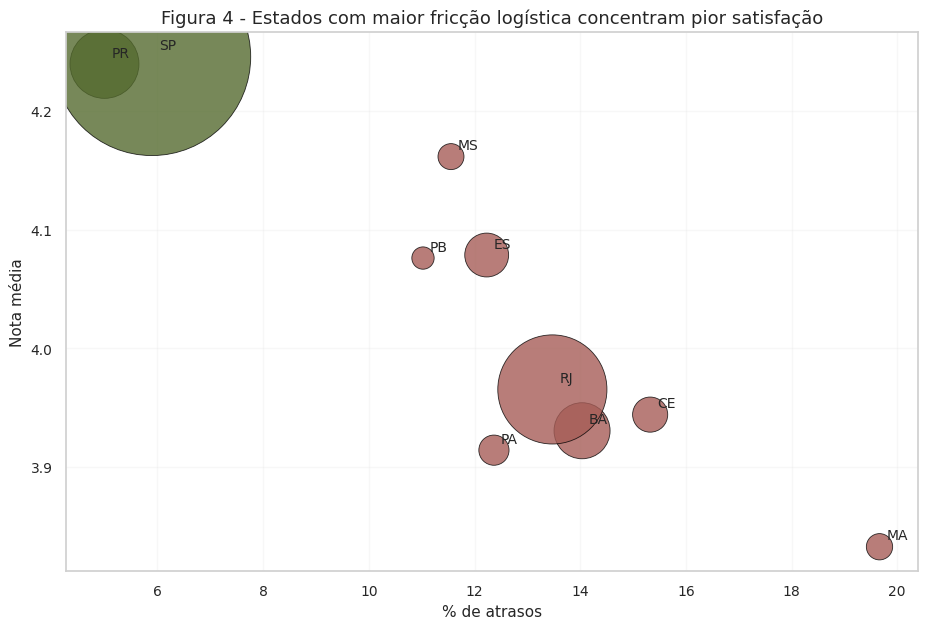

In [ ]:
# Figura Estados

ufs_grafico = ["MA", "CE", "BA", "RJ", "PA", "ES", "MS", "PB", "SP", "PR"]
estados_grafico = estados[estados["customer_state"].isin(ufs_grafico)].copy()

plt.figure(figsize=(11, 7))

cores = estados_grafico["customer_state"].apply(
    lambda x: "#A65D57" if x in ["MA", "CE", "BA", "RJ", "PA", "ES", "MS", "PB"] else "#556B2F"
)

plt.scatter(
    estados_grafico["perc_atrasos"],
    estados_grafico["nota_media"],
    s=estados_grafico["pedidos"] / 2,
    c=cores,
    alpha=0.8,
    edgecolors="black",
    linewidth=0.6
)

for _, row in estados_grafico.iterrows():
    plt.annotate(
        row["customer_state"],
        (row["perc_atrasos"], row["nota_media"]),
        xytext=(5, 5),
        textcoords="offset points",
        fontsize=10
    )

plt.xlabel("% de atrasos")
plt.ylabel("Nota média")
plt.title("Figura 4 - Estados com maior fricção logística concentram pior satisfação")
plt.grid(True, alpha=0.3)
plt.show()

In [ ]:
# Figura Categorias

categorias = (
    base_categoria
    .groupby("product_category_name_english", as_index=False)
    .agg(
        pedidos=("order_id", "nunique"),
        receita=("receita", "sum"),
        nota_media=("review_score", "mean"),
        perc_atrasos=("pedido_atrasado", "mean"),
        prazo_medio=("tempo_entrega_dias", "mean")
    )
)

categorias["ticket_medio"] = categorias["receita"] / categorias["pedidos"]
categorias["participacao_receita"] = categorias["receita"] / categorias["receita"].sum()
categorias["perc_atrasos"] = categorias["perc_atrasos"] * 100

categorias.sort_values("receita", ascending=False).head(10)

categorias_atencao = (
    categorias[categorias["pedidos"] >= 1200]
    .sort_values(["nota_media", "perc_atrasos"], ascending=[True, False])
    .head(8)
    .copy()
)

categorias_atencao

categorias_atencao_fmt = categorias_atencao.copy()

categorias_atencao_fmt["receita"] = categorias_atencao_fmt["receita"].map(
    lambda x: f"R$ {x:,.2f}".replace(",", "X").replace(".", ",").replace("X", ".")
)
categorias_atencao_fmt["ticket_medio"] = categorias_atencao_fmt["ticket_medio"].map(lambda x: f"{x:.2f}")
categorias_atencao_fmt["nota_media"] = categorias_atencao_fmt["nota_media"].map(lambda x: f"{x:.2f}")
categorias_atencao_fmt["perc_atrasos"] = categorias_atencao_fmt["perc_atrasos"].map(lambda x: f"{x:.1f}%")
categorias_atencao_fmt["prazo_medio"] = categorias_atencao_fmt["prazo_medio"].map(lambda x: f"{x:.1f}")
categorias_atencao_fmt["participacao_receita"] = categorias_atencao_fmt["participacao_receita"].map(lambda x: f"{x:.4f}")

categorias_atencao_fmt.rename(columns={
    "product_category_name_english": "Categoria",
    "pedidos": "Pedidos",
    "receita": "Receita",
    "ticket_medio": "Ticket médio",
    "nota_media": "Nota média",
    "perc_atrasos": "% atrasos",
    "prazo_medio": "Prazo médio (dias)",
    "participacao_receita": "Participação na receita"
}, inplace=True)

categorias_atencao_fmt


,Categoria,Pedidos,Receita,Nota média,% atrasos,Prazo médio (dias),Ticket médio,Participação na receita
57,office_furniture,1254,"R$ 335.211,36",3.64,9.2%,20.6,267.31,0.0220
7,bed_bath_table,9272,"R$ 1.225.209,26",4.00,8.7%,13.0,132.14,0.0805
68,telephony,4093,"R$ 379.202,62",4.05,8.5%,13.0,92.65,0.0249
39,furniture_decor,6307,"R$ 880.329,92",4.06,8.5%,13.1,139.58,0.0579
15,computers_accessories,6530,"R$ 1.032.723,77",4.08,7.7%,13.2,158.15,0.0679
6,baby,2809,"R$ 466.727,65",4.10,9.2%,12.7,166.15,0.0307
70,watches_gifts,5495,"R$ 1.264.333,12",4.12,8.5%,12.8,230.09,0.0831
26,electronics,2517,"R$ 200.723,09",4.12,9.8%,12.9,79.75,0.0132


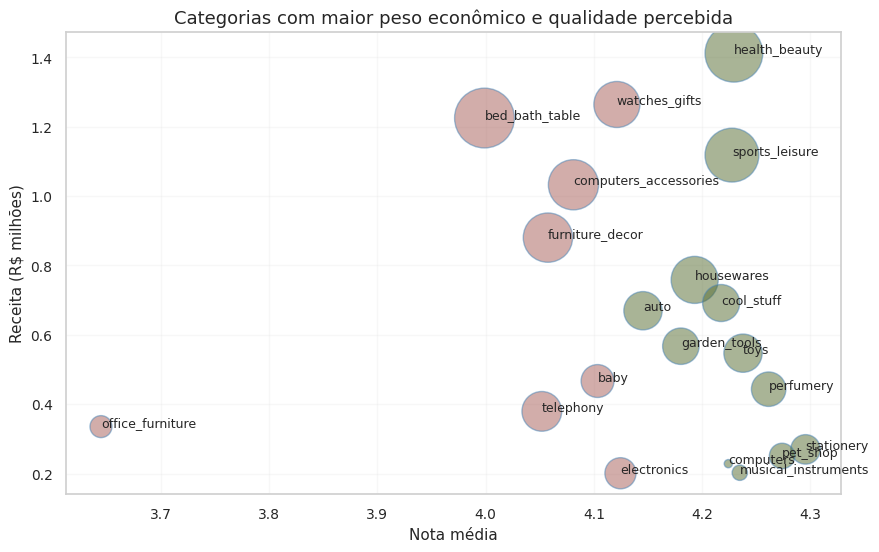

In [ ]:
# Figura Categorias

# exemplo: manter apenas as categorias mais relevantes em receita
categorias_plot = categorias.sort_values("receita", ascending=False).head(20).copy()

# se quiser garantir a inclusão de office_furniture, mesmo fora do top 20
extra = categorias[categorias["product_category_name_english"] == "office_furniture"]
categorias_plot = pd.concat([categorias_plot, extra]).drop_duplicates(
    subset="product_category_name_english"
)

categorias_plot["cor"] = categorias_plot["product_category_name_english"].apply(
    lambda x: TERRACOTA if x in categorias_atencao_nomes else VERDE
)

plt.figure(figsize=(10, 6))

plt.scatter(
    categorias_plot["nota_media"],
    categorias_plot["receita"] / 1_000_000,
    s=categorias_plot["pedidos"] / 5,
    c=categorias_plot["cor"],
    alpha=0.5,
    edgecolors="steelblue"
)

for _, row in categorias_plot.iterrows():
    plt.annotate(
        row["product_category_name_english"],
        (row["nota_media"], row["receita"] / 1_000_000),
        fontsize=9
    )

plt.xlabel("Nota média")
plt.ylabel("Receita (R$ milhões)")
plt.title("Categorias com maior peso econômico e qualidade percebida")
plt.grid(True, alpha=0.3)
plt.show()

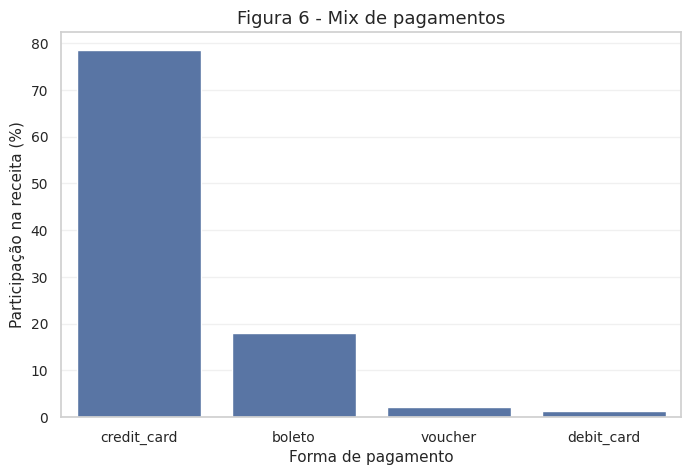

credit_card: 78.5%
boleto: 18.0%
voucher: 2.2%
debit_card: 1.4%


/tmp/ipykernel_3301/3682645003.py:25: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(


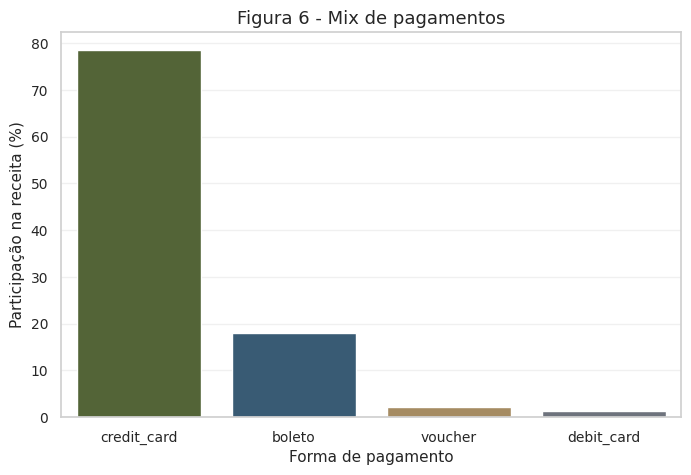

In [ ]:
# Figura Mix de Pagamentos

pagamentos_mix = (
    orders[orders["order_status"] == "delivered"][["order_id"]]
    .merge(payments, on="order_id", how="left")
    .groupby("payment_type", as_index=False)
    .agg(receita=("payment_value", "sum"))
    .sort_values("receita", ascending=False)
)

pagamentos_mix["participacao"] = pagamentos_mix["receita"] / pagamentos_mix["receita"].sum() * 100
pagamentos_mix

plt.figure(figsize=(8, 5))
sns.barplot(data=pagamentos_mix, x="payment_type", y="participacao")
plt.xlabel("Forma de pagamento")
plt.ylabel("Participação na receita (%)")
plt.title("Figura 6 - Mix de pagamentos")
plt.show()

for _, row in pagamentos_mix.iterrows():
    print(f"{row['payment_type']}: {row['participacao']:.1f}%")

plt.figure(figsize=(8, 5))
sns.barplot(
    data=pagamentos_mix,
    x="payment_type",
    y="participacao",
    palette=[VERDE, AZUL, DOURADO, CINZA]
)
plt.xlabel("Forma de pagamento")
plt.ylabel("Participação na receita (%)")
plt.title("Figura 6 - Mix de pagamentos")
plt.show()

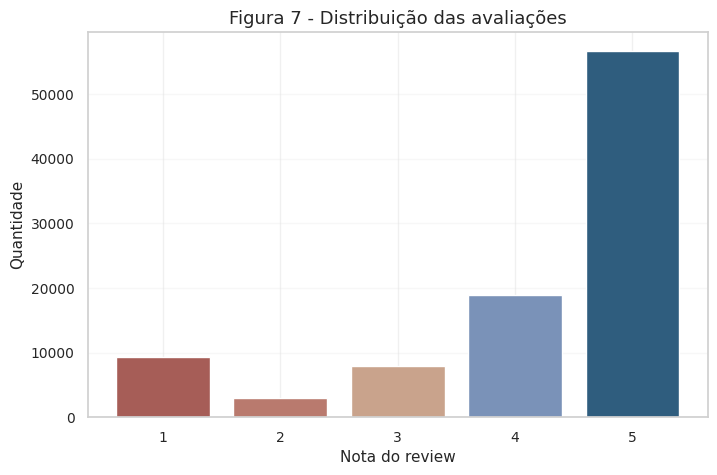

In [ ]:
# Figura Distribuição das Avaliações

palette_reviews = ["#A65D57", "#B97A6E", "#C9A38C", "#7A92B8", "#2F5D7E"]

contagem_reviews = (
    base_entregues["review_score"]
    .dropna()
    .astype(int)
    .value_counts()
    .sort_index()
    .reindex([1, 2, 3, 4, 5], fill_value=0)
)

plt.figure(figsize=(8, 5))
plt.bar(contagem_reviews.index, contagem_reviews.values, color=palette_reviews)

plt.xlabel("Nota do review")
plt.ylabel("Quantidade")
plt.title("Figura 7 - Distribuição das avaliações")
plt.xticks([1, 2, 3, 4, 5])
plt.grid(True, axis="y", alpha=0.3)
plt.show()

## 15 - Resumir KPIs

In [ ]:
# Nesta seção foram apresentados os principais indicadores do trabalho.

# Esses KPIs ajudaram a resumir os resultados da análise de forma objetiva.

kpis = {
    "Total de pedidos": base["order_id"].nunique(),
    "Total de clientes únicos": base["customer_unique_id"].nunique(),
    "Total de vendedores": base["seller_id"].nunique(),
    "Valor total movimentado": base["payment_value"].sum(),
    "Ticket médio": base.groupby("order_id")["payment_value"].sum().mean(),
    "Nota média de avaliação": base["review_score"].mean(),
    "Tempo médio de entrega em dias": base["tempo_entrega_dias"].mean(),
    "Percentual de pedidos atrasados": base["pedido_atrasado"].mean() * 100
}

kpis_df = pd.DataFrame(kpis.items(), columns=["Indicador", "Valor"])

kpis_df

kpis_df["Valor"] = kpis_df["Valor"].round(2)
kpis_df


,Indicador,Valor
0,Total de pedidos,99441.00
1,Total de clientes únicos,96096.00
2,Total de vendedores,3095.00
3,Valor total movimentado,20579664.01
4,Ticket médio,206.95
5,Nota média de avaliação,4.02
6,Tempo médio de entrega em dias,12.01
7,Percentual de pedidos atrasados,6.39


## 16 - Escrever conclusão

In [ ]:
# A análise exploratória permitiu observar padrões importantes no dataset da Olist, principalmente relacionados a vendas, logística e satisfação dos clientes.

# De forma geral, os dados indicam que o desempenho logístico possui relação relevante com a experiência do cliente, especialmente quando se observa a diferença entre pedidos entregues no prazo e pedidos atrasados.

# Também foi possível identificar categorias com maior volume de pedidos, variações no tempo de entrega e diferenças entre estados. Esses resultados ajudam a entender melhor o funcionamento do e-commerce e podem apoiar decisões sobre melhoria operacional, acompanhamento de vendedores e priorização de categorias ou regiões.